# PharmaTrade-MM Phase 4: PPO Price + Sentiment (Ablation 2)

This notebook mirrors Phase 3, but uses:
- `price_features + sentiment_features`

It supports tuned-parameter loading:
1) phase4 tuned params (`results/phase4_tuning/best_params_price_sentiment.json`)
2) warm-start from phase3 tuned params (`results/phase3_tuning/best_params_price_only.json`)


In [69]:
# Optional installs
%pip install gymnasium stable-baselines3 matplotlib



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [70]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    HAS_MATPLOTLIB = False
    print("matplotlib missing; plotting cells will be skipped.")

from phase2_trading_env import make_env_from_processed, DEFAULT_TICKERS

try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv
    SB3_AVAILABLE = True
except ModuleNotFoundError:
    SB3_AVAILABLE = False
    print("stable-baselines3 missing. Install it to train PPO.")


In [71]:
# Paths and config
TRAIN_PATH = "processed/train_dataset.csv"
TEST_PATH = "processed/test_dataset.csv"
FEATURE_CONFIG_PATH = "processed/feature_config.json"
XPH_PATH = "processed/xph_processed.csv"

RESULTS_DIR = Path("results/phase4_price_sentiment")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = RESULTS_DIR / "ppo_price_sentiment.zip"

PHASE4_TUNED = Path("results/phase4_tuning/best_params_price_sentiment.json")
PHASE3_TUNED = Path("results/phase3_tuning/best_params_price_only.json")
PHASE3_METRICS = Path("results/phase3_price_only/phase3_price_only_metrics.csv")

TOTAL_TIMESTEPS = 50_000
SEED = 42

with open(FEATURE_CONFIG_PATH, "r") as f:
    feature_cfg = json.load(f)

price_sent_features = feature_cfg["price_features"] + feature_cfg["sentiment_features"]
print("Num features (price+sentiment):", len(price_sent_features))

default_ppo_params = {
    "learning_rate": 3e-4,
    "n_steps": 2048,
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "ent_coef": 0.0,
    "vf_coef": 0.5,
    "clip_range": 0.2,
}

ppo_params = default_ppo_params.copy()
param_source = "default"
if PHASE4_TUNED.exists():
    with open(PHASE4_TUNED, "r") as f:
        ppo_params.update(json.load(f).get("best_params", {}))
    param_source = str(PHASE4_TUNED)
elif PHASE3_TUNED.exists():
    with open(PHASE3_TUNED, "r") as f:
        ppo_params.update(json.load(f).get("best_params", {}))
    param_source = str(PHASE3_TUNED)

print("PPO param source:", param_source)
print("PPO params:", ppo_params)


Num features (price+sentiment): 22
PPO param source: results/phase4_tuning/best_params_price_sentiment.json
PPO params: {'learning_rate': 0.00014312907952658717, 'n_steps': 512.0, 'batch_size': 512.0, 'n_epochs': 10.0, 'gamma': 0.995, 'gae_lambda': 0.9, 'ent_coef': 0.001, 'vf_coef': 0.75, 'clip_range': 0.3}


In [72]:
# Full run (recommended)
# This executes the latest Phase 4 script with anti-collapse guards.
import subprocess
import sys

cmd = [
    sys.executable,
    "phase4_price_sentiment_ppo.py",
    "--timesteps", "200000",
    "--search-timesteps", "60000",
    "--seeds", "7,42,123",
    "--val-split-date", "2021-01-01",
    "--sent-clip", "3.0",
    "--seed", "42",
]

print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)

Running: /usr/local/bin/python3 phase4_price_sentiment_ppo.py --timesteps 200000 --search-timesteps 60000 --seeds 7,42,123 --val-split-date 2021-01-01 --sent-clip 3.0 --seed 42
Using PPO params from: results/phase4_tuning/best_params_price_sentiment.json
Num features (price+sentiment): 22
Base PPO params: {'learning_rate': 0.00014312907952658717, 'n_steps': 512, 'batch_size': 512, 'n_epochs': 10, 'gamma': 0.995, 'gae_lambda': 0.9, 'ent_coef': 0.001, 'vf_coef': 0.75, 'clip_range': 0.3}
Robust seeds: [7, 42, 123]
Timesteps (final): 200000 | search: 60000
[candidate=base_tuned] score=-2.5262 sharpe=-2.0873 ret=0.2183 mdd=-0.0817 sell/hold/buy=0.416/0.435/0.149
[candidate=lower_lr_small_net] score=-3.4048 sharpe=-2.9198 ret=0.2007 mdd=-0.1802 sell/hold/buy=0.083/0.624/0.292
[candidate=low_lr_stable_steps] score=-3.8952 sharpe=-3.3773 ret=0.1858 mdd=-0.2331 sell/hold/buy=0.083/0.667/0.250
[candidate=no_exploration_late] score=-2.5420 sharpe=-2.0801 ret=0.2039 mdd=-0.0888 sell/hold/buy=0.375

CompletedProcess(args=['/usr/local/bin/python3', 'phase4_price_sentiment_ppo.py', '--timesteps', '200000', '--search-timesteps', '60000', '--seeds', '7,42,123', '--val-split-date', '2021-01-01', '--sent-clip', '3.0', '--seed', '42'], returncode=0)

In [73]:
# Build envs

def build_env(dataset_path: str):
    return make_env_from_processed(
        dataset_path=dataset_path,
        feature_config_path=FEATURE_CONFIG_PATH,
        tickers=DEFAULT_TICKERS,
        feature_columns_override=price_sent_features,
        initial_cash=1_000_000.0,
        transaction_cost=0.001,
        trade_fraction=0.10,
        use_event_scaling=False,
    )

train_env = build_env(TRAIN_PATH)
test_env = build_env(TEST_PATH)
obs, info = train_env.reset(seed=SEED)
print("Train obs shape:", obs.shape)
print("Train num features:", train_env.num_features)


Train obs shape: (185,)
Train num features: 22


In [74]:
# Train PPO
if not SB3_AVAILABLE:
    raise ModuleNotFoundError("stable-baselines3 not installed. Run install cell and retry.")

ppo_params["n_steps"] = int(ppo_params["n_steps"])
ppo_params["batch_size"] = int(ppo_params["batch_size"])
ppo_params["n_epochs"] = int(ppo_params["n_epochs"])

vec_train_env = DummyVecEnv([lambda: build_env(TRAIN_PATH)])
model = PPO("MlpPolicy", vec_train_env, verbose=1, seed=SEED, **ppo_params)
model.learn(total_timesteps=TOTAL_TIMESTEPS)
model.save(str(MODEL_PATH))
print("Saved model:", MODEL_PATH)


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 3042 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2851        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.005027357 |
|    clip_fraction        | 0.000781    |
|    clip_range           | 0.3         |
|    entropy_loss         | -8.79       |
|    explained_variance   | -2.06       |
|    learning_rate        | 0.000143    |
|    loss                 | 0.0907      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0124     |
|    value_loss           | 0.179       |
-----------------------------------------
-----------------

In [75]:
# Backtest PPO

def run_ppo_backtest(env, trained_model):
    obs, info = env.reset(seed=SEED)
    done = False
    rows, action_rows = [], []

    while not done:
        action, _ = trained_model.predict(obs, deterministic=True)
        obs, reward, done, _, step_info = env.step(action)
        rows.append({
            "date": step_info["date"],
            "portfolio_value": step_info["portfolio_value"],
            "daily_return": step_info["daily_return"],
            "reward": reward,
            "drawdown": step_info["drawdown"],
            "sharpe": step_info["sharpe"],
            "cvar_penalty": step_info["cvar_penalty"],
        })
        a = np.asarray(action).reshape(-1)
        action_rows.append({"date": step_info["date"], **{f"act_{t}": int(a[i]) for i, t in enumerate(DEFAULT_TICKERS)}})

    perf = pd.DataFrame(rows)
    perf["date"] = pd.to_datetime(perf["date"])
    perf = perf.sort_values("date").reset_index(drop=True)

    actions = pd.DataFrame(action_rows)
    actions["date"] = pd.to_datetime(actions["date"])
    actions = actions.sort_values("date").reset_index(drop=True)
    return perf, actions

ppo_perf, ppo_actions = run_ppo_backtest(test_env, model)
ppo_perf.head()


,date,portfolio_value,daily_return,reward,drawdown,sharpe,cvar_penalty
0,2022-01-04,9.999001e+05,-0.000100,-0.000110,0.000100,0.000000,0.0
1,2022-01-05,9.995424e+05,-0.000090,-10.736810,0.000458,-214.733477,0.0
2,2022-01-06,1.000724e+06,-0.000081,3.209389,0.000000,-150.544072,0.0
3,2022-01-07,9.997207e+05,-0.000073,1.665802,0.001003,-117.224572,0.0
4,2022-01-10,1.004300e+06,-0.000065,1.107887,0.000000,-95.065530,0.0


In [76]:
# Baselines + metrics

test_df = pd.read_csv(TEST_PATH, parse_dates=["date"])
prices = test_df.pivot(index="date", columns="ticker", values="close").sort_index()[DEFAULT_TICKERS]


def max_drawdown(equity):
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())


def sharpe(daily):
    s = daily.std(ddof=1)
    if s <= 1e-12:
        return 0.0
    return float((daily.mean()/s)*np.sqrt(252))


def sortino(daily):
    d = daily[daily<0]
    ds = d.std(ddof=1) if len(d)>1 else 0.0
    if ds <= 1e-12:
        return 0.0
    return float((daily.mean()/ds)*np.sqrt(252))


def win_rate(daily):
    return float((daily > 0).mean())


def simulate_buy_hold_equal(prices):
    shares = (1_000_000.0 / len(prices.columns)) / prices.iloc[0]
    equity = (prices * shares).sum(axis=1)
    daily = equity.pct_change().fillna(0.0)
    return equity, daily


def simulate_equal_weight_monthly(prices, tc=0.001):
    dates = prices.index
    n = prices.shape[1]
    target = np.repeat(1.0/n, n)
    w = target.copy()
    eq = [1_000_000.0]
    prev_month = dates[0].month
    for i in range(1, len(dates)):
        r = prices.iloc[i].values / prices.iloc[i-1].values - 1.0
        v = eq[-1] * (1.0 + float(np.dot(w, r)))
        numer = w * (1.0 + r)
        den = numer.sum()
        w = numer / den if den > 0 else target.copy()
        if dates[i].month != prev_month:
            turnover = np.abs(target - w).sum()
            v = v * (1.0 - tc * turnover)
            w = target.copy()
        prev_month = dates[i].month
        eq.append(v)
    eq = pd.Series(eq, index=dates)
    return eq, eq.pct_change().fillna(0.0)


def simulate_momentum_20d(prices, top_k=3, tc=0.001):
    dates = prices.index
    n = prices.shape[1]
    mom = prices.pct_change(20).shift(1)
    w = np.zeros(n)
    eq = [1_000_000.0]
    for i in range(1, len(dates)):
        m = mom.iloc[i].values
        valid = np.where(np.isfinite(m) & (m > 0))[0]
        target = np.zeros(n)
        if len(valid) > 0:
            pick = valid[np.argsort(m[valid])[::-1]][:top_k]
            target[pick] = 1.0 / len(pick)
        turnover = np.abs(target - w).sum()
        v = eq[-1] * (1.0 - tc * turnover)
        r = prices.iloc[i].values / prices.iloc[i-1].values - 1.0
        v = v * (1.0 + float(np.dot(target, r)))
        w = target
        eq.append(v)
    eq = pd.Series(eq, index=dates)
    return eq, eq.pct_change().fillna(0.0)


def normalize_to_1m(s):
    return s / s.iloc[0] * 1_000_000.0

bh_eq, bh_daily = simulate_buy_hold_equal(prices)
ew_eq, ew_daily = simulate_equal_weight_monthly(prices)
mo_eq, mo_daily = simulate_momentum_20d(prices)

xph = pd.read_csv(XPH_PATH, parse_dates=["date"]).sort_values("date")
xph = xph[(xph["date"]>=prices.index.min()) & (xph["date"]<=prices.index.max())]
xph_eq = normalize_to_1m(xph.set_index("date")["close"])
xph_daily = xph_eq.pct_change().fillna(0.0)

ppo_eq = ppo_perf.set_index("date")["portfolio_value"]
ppo_daily = ppo_eq.pct_change().fillna(0.0)


def metrics(name, eq, daily, xph_daily):
    idx = daily.index.intersection(xph_daily.index)
    r = daily.loc[idx]
    xr = xph_daily.loc[idx]
    ex = r - xr
    return {
        "strategy": name,
        "cumulative_return_pct": float((eq.iloc[-1]/eq.iloc[0]-1.0)*100),
        "ann_sharpe": sharpe(r),
        "ann_sortino": sortino(r),
        "max_drawdown_pct": float(max_drawdown(eq)*100),
        "win_rate": win_rate(r),
        "alpha_vs_xph_ann_pct": float(ex.mean()*252*100),
    }

metrics_df = pd.DataFrame([
    metrics("PPO_PriceSentiment", ppo_eq, ppo_daily, xph_daily),
    metrics("BuyHold_Equal", bh_eq, bh_daily, xph_daily),
    metrics("EqualWeight_Monthly", ew_eq, ew_daily, xph_daily),
    metrics("Momentum_20D", mo_eq, mo_daily, xph_daily),
    metrics("XPH", xph_eq, xph_daily, xph_daily),
]).sort_values("ann_sharpe", ascending=False).reset_index(drop=True)

metrics_df


,strategy,cumulative_return_pct,ann_sharpe,ann_sortino,max_drawdown_pct,win_rate,alpha_vs_xph_ann_pct
0,BuyHold_Equal,9.625921,0.377820,0.613220,-17.925456,0.508982,7.737318
1,EqualWeight_Monthly,8.460957,0.339634,0.554942,-18.982354,0.500998,7.237284
2,PPO_PriceSentiment,-2.700687,0.001324,0.002046,-18.387630,0.483034,2.205872
3,XPH,-8.074730,-0.090723,-0.145941,-22.619079,0.491018,0.000000
4,Momentum_20D,-8.401114,-0.171261,-0.254539,-24.221550,0.465070,-0.998788


In [77]:
# Save artifacts + Phase3 vs Phase4 comparison
metrics_path = RESULTS_DIR / "phase4_price_sentiment_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

curve_df = pd.DataFrame({
    "date": ppo_eq.index,
    "ppo_price_sentiment": ppo_eq.values,
    "buy_hold_equal": bh_eq.reindex(ppo_eq.index).values,
    "equal_weight_monthly": ew_eq.reindex(ppo_eq.index).values,
    "momentum_20d": mo_eq.reindex(ppo_eq.index).values,
    "xph": xph_eq.reindex(ppo_eq.index).values,
})
curve_path = RESULTS_DIR / "phase4_price_sentiment_equity_curve.csv"
curve_df.to_csv(curve_path, index=False)

actions_path = RESULTS_DIR / "phase4_price_sentiment_actions.csv"
ppo_actions.to_csv(actions_path, index=False)

comp_path = RESULTS_DIR / "phase3_vs_phase4_comparison.csv"
if PHASE3_METRICS.exists():
    p3 = pd.read_csv(PHASE3_METRICS)
    p3_row = p3[p3["strategy"] == "PPO_PriceOnly"].head(1)
    p4_row = metrics_df[metrics_df["strategy"] == "PPO_PriceSentiment"].head(1)
    if not p3_row.empty and not p4_row.empty:
        keep = ["cumulative_return_pct", "ann_sharpe", "ann_sortino", "max_drawdown_pct", "alpha_vs_xph_ann_pct"]
        comp = pd.DataFrame({
            "metric": keep,
            "phase3_price_only": [float(p3_row.iloc[0][m]) for m in keep],
            "phase4_price_sentiment": [float(p4_row.iloc[0][m]) for m in keep],
        })
        comp["delta_p4_minus_p3"] = comp["phase4_price_sentiment"] - comp["phase3_price_only"]
        comp.to_csv(comp_path, index=False)
        display(comp)

print("Saved:")
print(" -", metrics_path)
print(" -", curve_path)
print(" -", actions_path)
if comp_path.exists():
    print(" -", comp_path)


,metric,phase3_price_only,phase4_price_sentiment,delta_p4_minus_p3
0,cumulative_return_pct,12.106765,-2.700687,-14.807452
1,ann_sharpe,0.445379,0.001324,-0.444055
2,ann_sortino,0.718082,0.002046,-0.716037
3,max_drawdown_pct,-15.215891,-18.387630,-3.171740
4,alpha_vs_xph_ann_pct,9.152787,2.205872,-6.946915


Saved:
 - results/phase4_price_sentiment/phase4_price_sentiment_metrics.csv
 - results/phase4_price_sentiment/phase4_price_sentiment_equity_curve.csv
 - results/phase4_price_sentiment/phase4_price_sentiment_actions.csv
 - results/phase4_price_sentiment/phase3_vs_phase4_comparison.csv


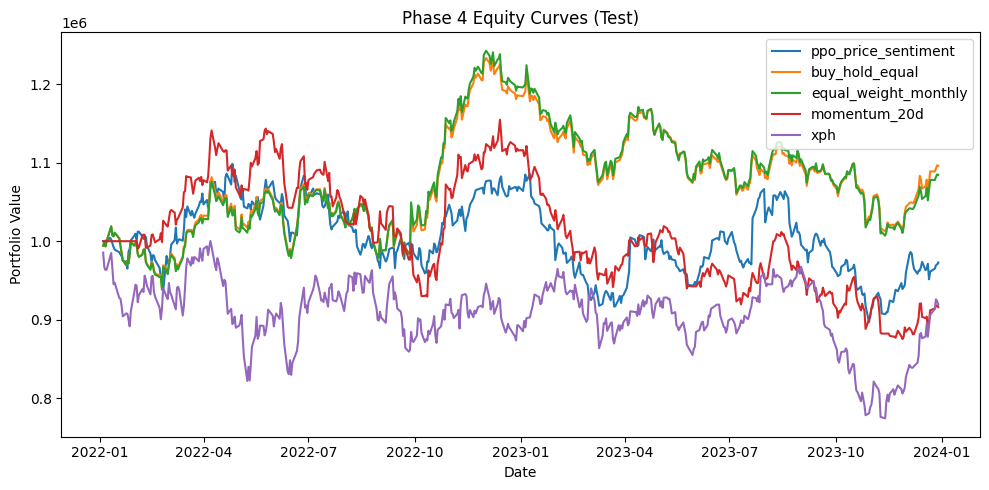

In [78]:
# Sanity checks + plots
assert not curve_df.isnull().any().any(), "NaN found in phase4 curve"
assert (curve_df[[c for c in curve_df.columns if c != "date"]] > 0).all().all(), "Non-positive values found"
assert len(ppo_actions) == len(ppo_perf), "Action length mismatch"

if HAS_MATPLOTLIB:
    plt.figure(figsize=(10,5))
    for c in ["ppo_price_sentiment","buy_hold_equal","equal_weight_monthly","momentum_20d","xph"]:
        plt.plot(curve_df["date"], curve_df[c], label=c)
    plt.title("Phase 4 Equity Curves (Test)")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Plot skipped (matplotlib missing).")


## Phase 4 Completion Checklist

- PPO price+sentiment model trained and saved
- Test backtest executed
- Baselines computed
- Metrics exported
- Phase3 vs Phase4 comparison exported
